In [2]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


In [0]:
# Import important library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

# 1. Launch a new python notebook and read the data set. EDA & Pre-processing (Make sure to remove all non-numeric entries from numeric columns) – 5 points


In [4]:
car_mpg = pd.read_csv('/content/drive/My Drive/Machine Learning/Assignments/External/Residency 4 External Assignment/Unsupervised Learning/cars-dataset.csv')
car_mpg.head(10)

,car name,cyl,disp,hp,wt,acc,yr,mpg
0,chevrolet chevelle malibu,8,307.0,130,3504,12.0,70,18.0
1,buick skylark 320,8,350.0,165,3693,11.5,70,15.0
2,plymouth satellite,8,318.0,150,3436,11.0,70,18.0
3,amc rebel sst,8,304.0,150,3433,12.0,70,16.0
4,ford torino,8,302.0,140,3449,10.5,70,17.0
5,ford galaxie 500,8,429.0,198,4341,10.0,70,15.0
6,chevrolet impala,8,454.0,220,4354,9.0,70,14.0
7,plymouth fury iii,8,440.0,215,4312,8.5,70,14.0
8,pontiac catalina,8,455.0,225,4425,10.0,70,14.0
9,amc ambassador dpl,8,390.0,190,3850,8.5,70,15.0


In [5]:
car_mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
car name    398 non-null object
cyl         398 non-null int64
disp        398 non-null float64
hp          398 non-null object
wt          398 non-null int64
acc         398 non-null float64
yr          398 non-null int64
mpg         398 non-null float64
dtypes: float64(3), int64(3), object(2)
memory usage: 25.0+ KB


In [6]:
car_mpg.describe().T

,count,mean,std,min,25%,50%,75%,max
cyl,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
disp,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
wt,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acc,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
yr,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6


In [7]:
temp = pd.DataFrame(car_mpg.hp.str.isdigit()) 
temp[temp['hp'] == False]

,hp
32,False
126,False
330,False
336,False
354,False
374,False


In [0]:
car_mpg = car_mpg.replace('?', np.nan)

In [9]:
car_mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
car name    398 non-null object
cyl         398 non-null int64
disp        398 non-null float64
hp          392 non-null object
wt          398 non-null int64
acc         398 non-null float64
yr          398 non-null int64
mpg         398 non-null float64
dtypes: float64(3), int64(3), object(2)
memory usage: 25.0+ KB


In [0]:
car_mpg['hp'] = car_mpg['hp'].astype('float64')

In [11]:
numeric_cols = car_mpg.drop('car name', axis=1)

car_names = pd.DataFrame(car_mpg[['car name']])


numeric_cols = numeric_cols.apply(lambda x: x.fillna(x.median()),axis=0)
car_mpg = numeric_cols.join(car_names)  

car_mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
cyl         398 non-null int64
disp        398 non-null float64
hp          398 non-null float64
wt          398 non-null int64
acc         398 non-null float64
yr          398 non-null int64
mpg         398 non-null float64
car name    398 non-null object
dtypes: float64(4), int64(3), object(1)
memory usage: 25.0+ KB


In [12]:
car_mpg.describe()

,cyl,disp,hp,wt,acc,yr,mpg
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,5.454774,193.425879,104.304020,2970.424623,15.568090,76.010050,23.514573
std,1.701004,104.269838,38.222625,846.841774,2.757689,3.697627,7.815984
min,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,9.000000
25%,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,17.500000
50%,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,23.000000
75%,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,29.000000
max,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,46.600000


# 2.Use pair plot or scatter matrix to visualize how the different variables are related (Hint: The amount of Gaussian curves in the plot should give a visual identification of different clusters existing in the dataset) – 5 points

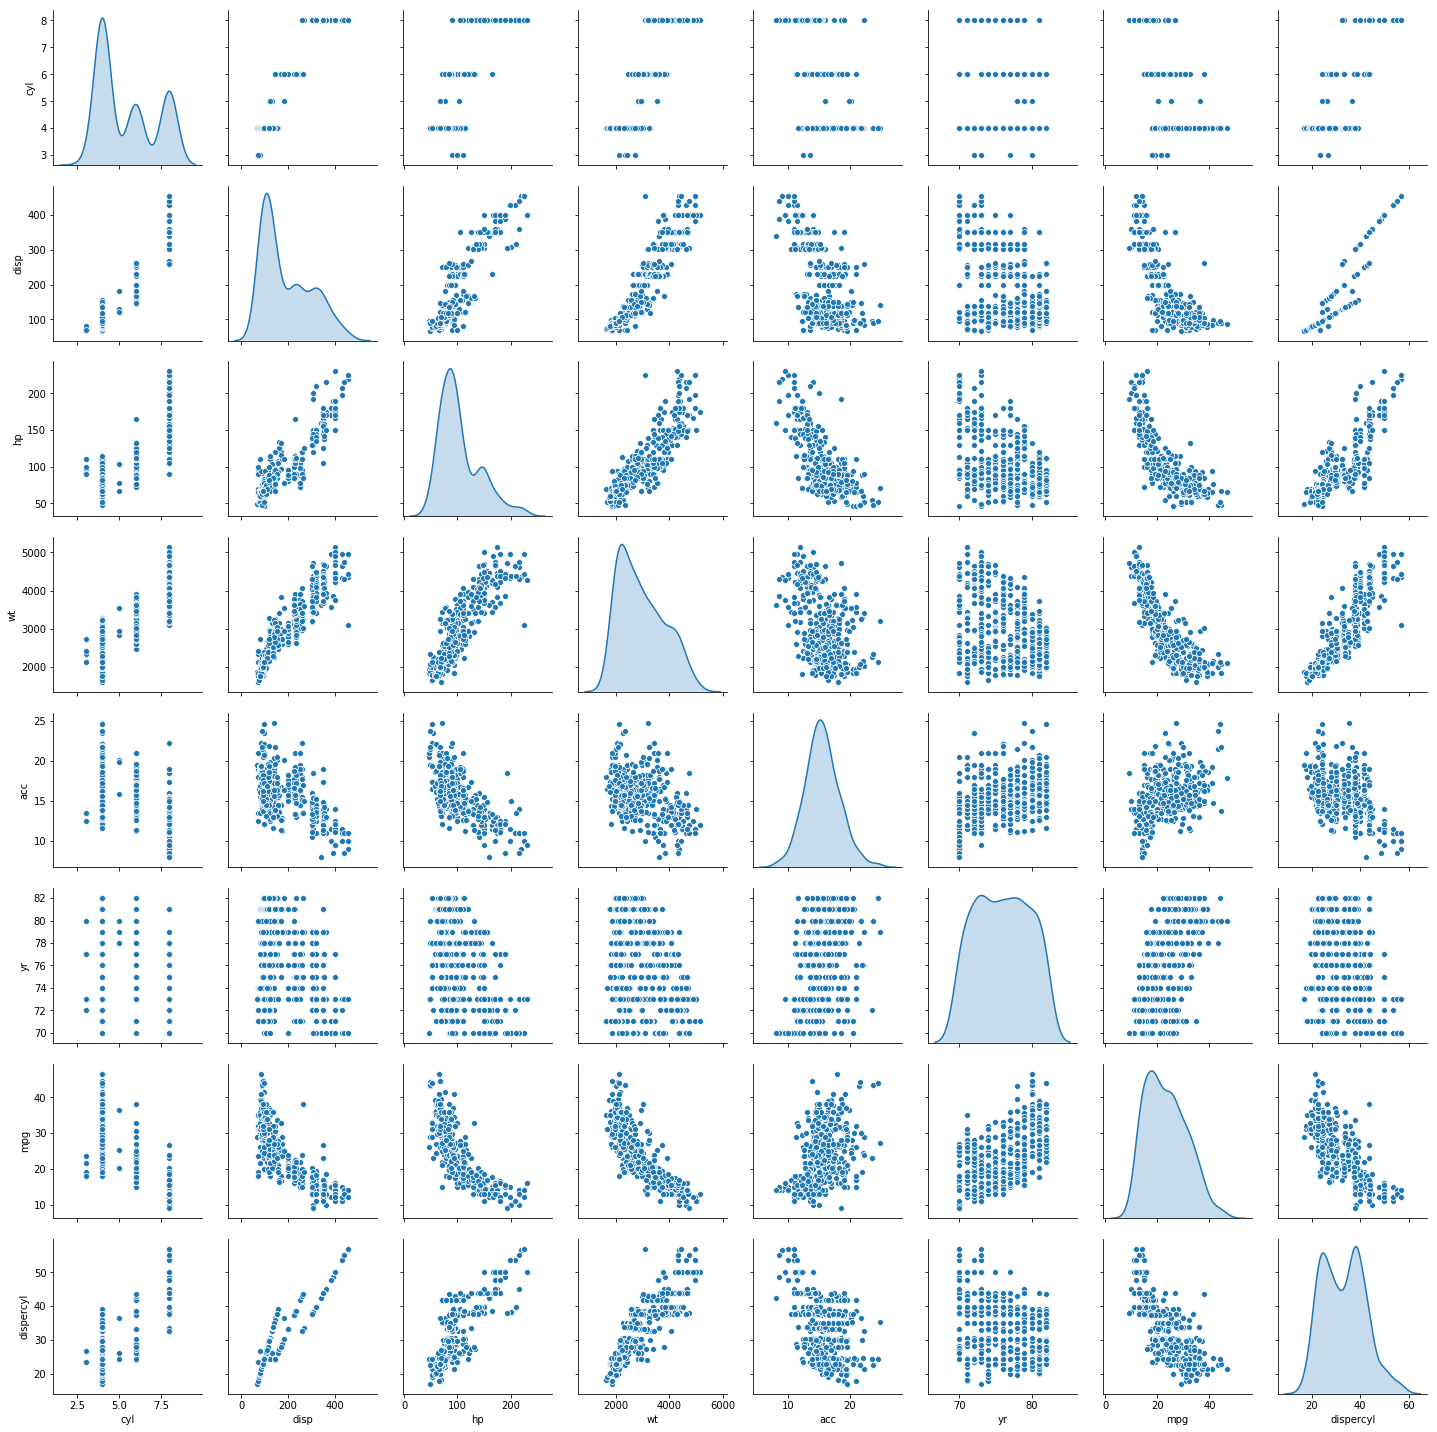

In [13]:
car_mpg_attr = car_mpg.iloc[:, 0:9]
car_mpg_attr['dispercyl'] = car_mpg_attr['disp'] / car_mpg_attr['cyl']
sns.pairplot(car_mpg_attr, diag_kind='kde')

# 3.Use K Means or Hierarchical clustering to find out the optimal number of clusters in the data. Identify and separate the clusters (10 points)

In [14]:
cluster_range = range( 2, 6 )   # expect 3 to four clusters from the pair panel visual inspection hence restricting from 2 to 6
cluster_errors = []
for num_clusters in cluster_range:
  clusters = KMeans( num_clusters, n_init = 5)
  clusters.fit(numeric_cols)
  labels = clusters.labels_
  centroids = clusters.cluster_centers_
  cluster_errors.append( clusters.inertia_ )
clusters_df = pd.DataFrame( { "num_clusters":cluster_range, "cluster_errors": cluster_errors } )
clusters_df[0:15]

,num_clusters,cluster_errors
0,2,7.428941e+07
1,3,3.420799e+07
2,4,1.905671e+07
3,5,1.376961e+07


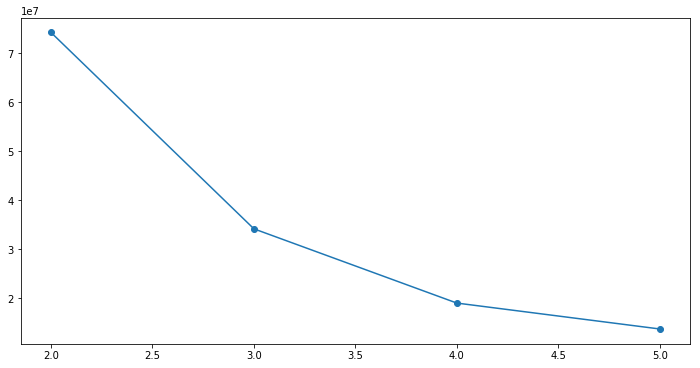

In [15]:
plt.figure(figsize=(12,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" )

In [0]:
# number of clusters = 3

from sklearn.cluster import KMeans
from scipy.stats import zscore

#car_mpg_attr = car_mpg.loc[:, 'mpg']
car_mpg_attr_z = numeric_cols.apply(zscore)

cluster = KMeans( n_clusters = 3, random_state = 0 )
cluster.fit(car_mpg_attr_z)

prediction=cluster.predict(car_mpg_attr_z)
car_mpg_attr_z["GROUP"] = prediction     # Creating a new column "GROUP" which will hold the cluster id of each record

car_mpg_attr_z_copy = car_mpg_attr_z.copy(deep = True)  # Creating a mirror copy for later re-use instead of building repeatedly

In [38]:
centroids = cluster.cluster_centers_
centroids

array([[-0.85049257, -0.79706235, -0.55430755, -0.75031913,  0.32038249,
        -0.64348788,  0.19751875],
       [ 0.42558031,  0.30810076, -0.03401386,  0.34575408,  0.29922485,
         0.05143538, -0.49876792],
       [-0.82506599, -0.78402235, -0.74329094, -0.77275084,  0.37884159,
         1.10677463,  1.18881992],
       [ 1.49819126,  1.50392292,  1.52168282,  1.40409797, -1.0861486 ,
        -0.68832385, -1.16379715]])

In [40]:
#centroid_df = pd.DataFrame(centroids, columns = list(mpg_df_attr) )
centroid_df = pd.DataFrame(centroids, columns = list(numeric_cols) )
centroid_df

,cyl,disp,hp,wt,acc,yr,mpg
0,-0.850493,-0.797062,-0.554308,-0.750319,0.320382,-0.643488,0.197519
1,0.425580,0.308101,-0.034014,0.345754,0.299225,0.051435,-0.498768
2,-0.825066,-0.784022,-0.743291,-0.772751,0.378842,1.106775,1.188820
3,1.498191,1.503923,1.521683,1.404098,-1.086149,-0.688324,-1.163797


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fd5dc7b0eb8>,
      dtype=object)

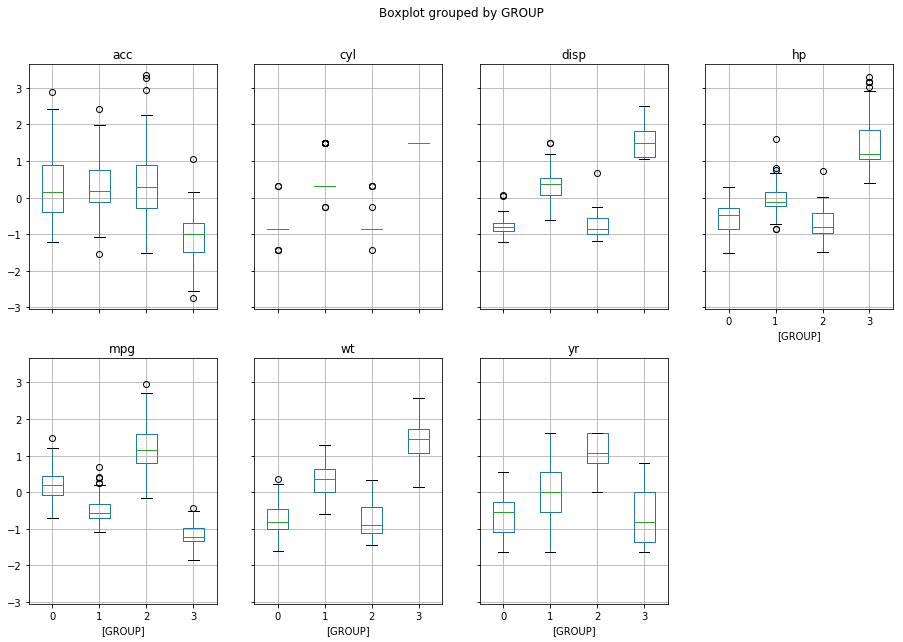

In [41]:
import matplotlib.pylab as plt

car_mpg_attr_z.boxplot(by = 'GROUP',  layout=(2,4), figsize=(15, 10))

In [0]:
# Addressing outliers at group level

data = car_mpg_attr_z   
       
def replace(group):
    median, std = group.median(), group.std()  #Get the median and the standard deviation of every group 
    outliers = (group - median).abs() > 2*std # Subtract median from every member of each group. Take absolute values > 2std
    group[outliers] = group.median()       
    return group

data_corrected = (data.groupby('GROUP').transform(replace)) 
concat_data = data_corrected.join(pd.DataFrame(car_mpg_attr_z['GROUP']))


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fd5dc062208>,
      dtype=object)

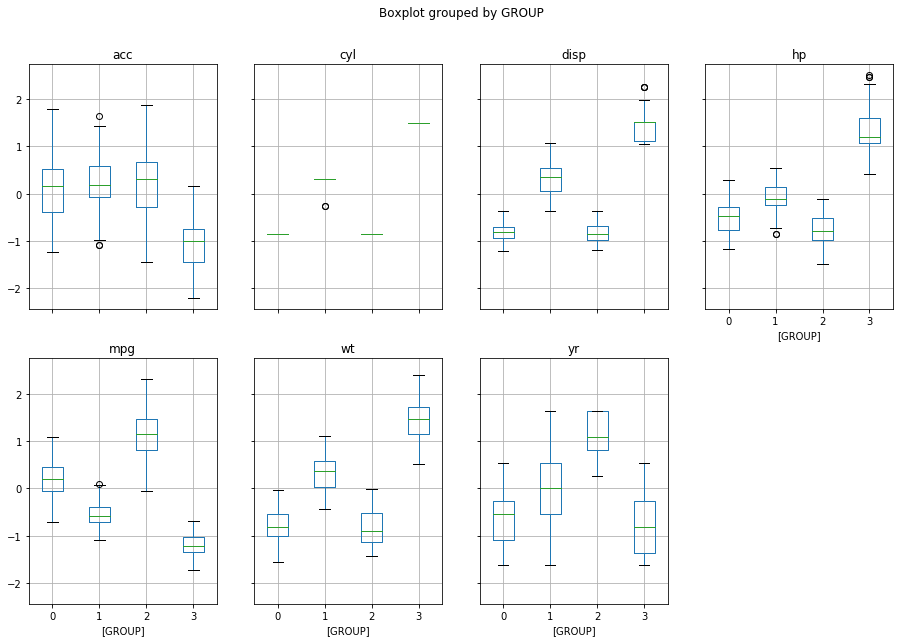

In [43]:
concat_data.boxplot(by = 'GROUP', layout=(2,4), figsize=(15, 10))

In [0]:
largecar = concat_data[concat_data['GROUP']==0]
smallcar = concat_data[concat_data['GROUP']==1]
sedancar = concat_data[concat_data['GROUP']==2]


In [45]:
largecar.head()

,cyl,disp,hp,wt,acc,yr,mpg,GROUP
14,-0.856321,-0.772295,-0.243723,-0.707544,-0.206262,-1.627426,0.062185,0
17,-0.856321,-0.801103,-0.505677,-0.453340,0.156817,-1.627426,-0.322127,0
18,-0.856321,-0.925936,-0.427091,-0.993671,-0.387801,-1.627426,0.446497,0
19,-0.856321,-0.925936,-0.479482,-1.342463,1.790672,-1.627426,0.318393,0
20,-0.856321,-0.801103,-0.453287,-0.352841,0.701436,-1.627426,0.190289,0


In [0]:
# number of clusters = 4

from sklearn.cluster import KMeans
from scipy.stats import zscore

#car_mpg_attr = car_mpg.loc[:, 'mpg']
car_mpg_attr_z = numeric_cols.apply(zscore)

cluster = KMeans( n_clusters = 4, random_state = 0 )
cluster.fit(car_mpg_attr_z)

prediction=cluster.predict(car_mpg_attr_z)
car_mpg_attr_z["GROUP"] = prediction     # Creating a new column "GROUP" which will hold the cluster id of each record

car_mpg_attr_z_copy = car_mpg_attr_z.copy(deep = True)  # Creating a mirror copy for later re-use instead of building repeatedly

In [24]:
centroids = cluster.cluster_centers_
centroids

array([[-0.85049257, -0.79706235, -0.55430755, -0.75031913,  0.32038249,
        -0.64348788,  0.19751875],
       [ 0.42558031,  0.30810076, -0.03401386,  0.34575408,  0.29922485,
         0.05143538, -0.49876792],
       [-0.82506599, -0.78402235, -0.74329094, -0.77275084,  0.37884159,
         1.10677463,  1.18881992],
       [ 1.49819126,  1.50392292,  1.52168282,  1.40409797, -1.0861486 ,
        -0.68832385, -1.16379715]])

In [25]:
centroid_df = pd.DataFrame(centroids, columns = list(numeric_cols) )
centroid_df

,cyl,disp,hp,wt,acc,yr,mpg
0,-0.850493,-0.797062,-0.554308,-0.750319,0.320382,-0.643488,0.197519
1,0.425580,0.308101,-0.034014,0.345754,0.299225,0.051435,-0.498768
2,-0.825066,-0.784022,-0.743291,-0.772751,0.378842,1.106775,1.188820
3,1.498191,1.503923,1.521683,1.404098,-1.086149,-0.688324,-1.163797


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fd5dd1d2a20>,
      dtype=object)

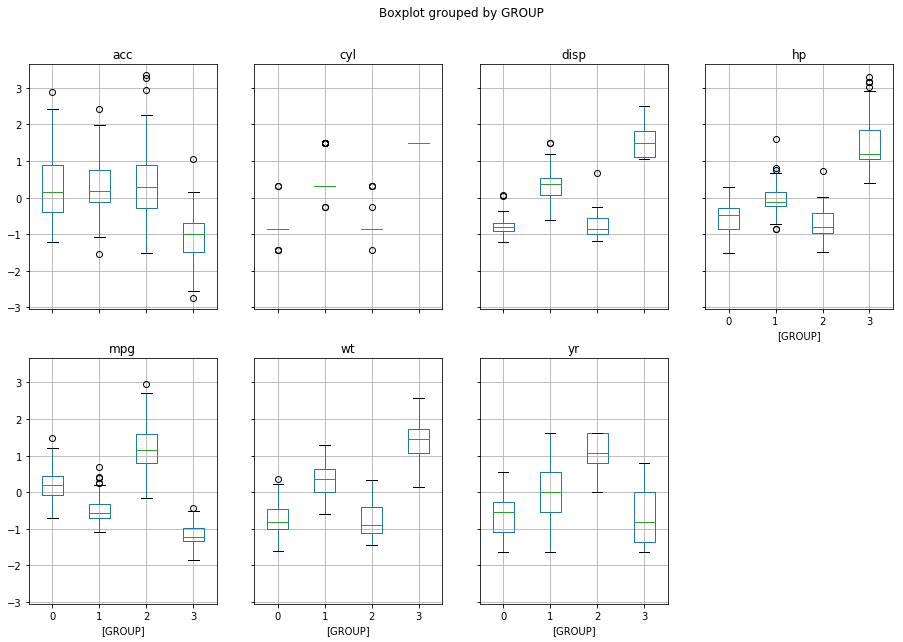

In [26]:
import matplotlib.pylab as plt

car_mpg_attr_z.boxplot(by = 'GROUP',  layout=(2,4), figsize=(15, 10))

In [0]:
# Addressing outliers at group level

data = car_mpg_attr_z   
       
def replace(group):
    median, std = group.median(), group.std()  #Get the median and the standard deviation of every group 
    outliers = (group - median).abs() > 2*std # Subtract median from every member of each group. Take absolute values > 2std
    group[outliers] = group.median()       
    return group

data_corrected = (data.groupby('GROUP').transform(replace)) 
concat_data = data_corrected.join(pd.DataFrame(car_mpg_attr_z['GROUP']))

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fd5dcc58390>,
      dtype=object)

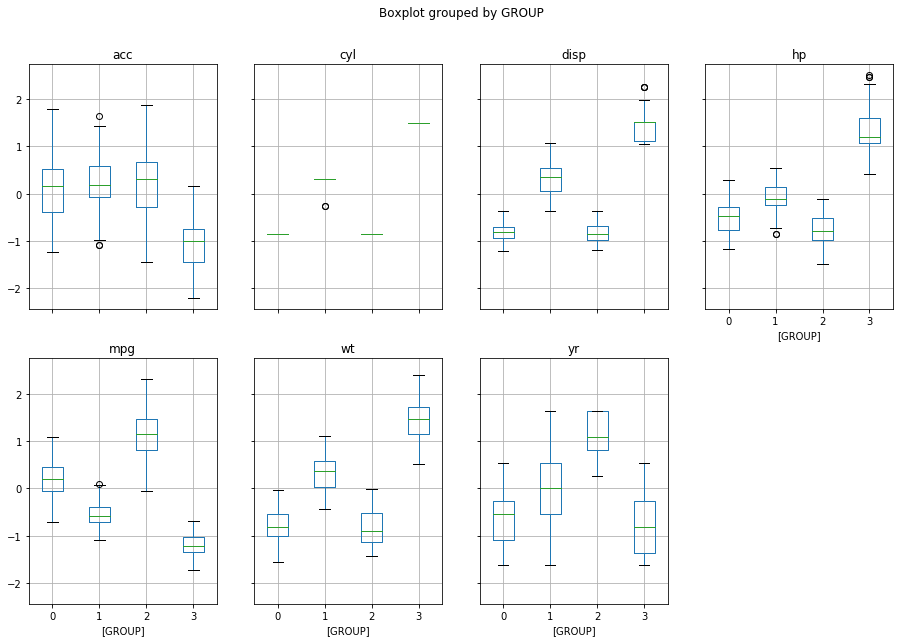

In [28]:
concat_data.boxplot(by = 'GROUP', layout=(2,4), figsize=(15, 10))

In [0]:
largecar1 = concat_data[concat_data['GROUP']==0]
smallcar1 = concat_data[concat_data['GROUP']==1]
sedancar1 = concat_data[concat_data['GROUP']==2]
minicar1 = concat_data[concat_data['GROUP']==3]


# 4.Use linear regression model on different clusters separately and print the coefficients of the models individually (10 points)

In [0]:
largecar_df = largecar.drop('yr', axis=1)
smallcar_df = smallcar.drop('yr', axis=1)
sedancar_df = sedancar.drop('yr', axis=1)
largecar1_df = largecar1.drop('yr', axis=1)
smallcar1_df = smallcar1.drop('yr', axis=1)
sedancar1_df = sedancar1.drop('yr', axis=1)
minicar1_df = minicar1.drop('yr', axis=1)

In [47]:
largecar_df.head()

,cyl,disp,hp,wt,acc,mpg,GROUP
14,-0.856321,-0.772295,-0.243723,-0.707544,-0.206262,0.062185,0
17,-0.856321,-0.801103,-0.505677,-0.453340,0.156817,-0.322127,0
18,-0.856321,-0.925936,-0.427091,-0.993671,-0.387801,0.446497,0
19,-0.856321,-0.925936,-0.479482,-1.342463,1.790672,0.318393,0
20,-0.856321,-0.801103,-0.453287,-0.352841,0.701436,0.190289,0


In [0]:
# linear model for 3 clusters.
# 1. largecar

X = largecar_df[['cyl', 'disp', 'hp', 'wt', 'acc']]
y = largecar_df['mpg']

In [55]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [59]:
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[idx]))

The coefficient for cyl is 0.0
The coefficient for disp is -0.070187836592602
The coefficient for hp is -0.5050510637963371
The coefficient for wt is -0.4325558027706103
The coefficient for acc is -0.08529878206248534


In [62]:
# 2. smallcar

X = smallcar_df[['cyl', 'disp', 'hp', 'wt', 'acc']]
y = smallcar_df['mpg']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[idx]))

The coefficient for cyl is -0.1477969578809992
The coefficient for disp is -0.08945243844319005
The coefficient for hp is 0.047508239570562244
The coefficient for wt is -0.20101295013655754
The coefficient for acc is -0.01857754468899228


In [64]:
# 3. sedancar

X = sedancar_df[['cyl', 'disp', 'hp', 'wt', 'acc']]
y = sedancar_df['mpg']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[idx]))

The coefficient for cyl is 0.0
The coefficient for disp is -1.3523720105226171
The coefficient for hp is -0.019265041493573443
The coefficient for wt is -0.08053651115085392
The coefficient for acc is -0.08288021473324932


In [65]:
# Linear model for 4 clusters
#1. largecar1

X = largecar1_df[['cyl', 'disp', 'hp', 'wt', 'acc']]
y = largecar1_df['mpg']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[idx]))

The coefficient for cyl is 0.0
The coefficient for disp is -0.070187836592602
The coefficient for hp is -0.5050510637963371
The coefficient for wt is -0.4325558027706103
The coefficient for acc is -0.08529878206248534


In [66]:
# 2. smallcar1

X = smallcar1_df[['cyl', 'disp', 'hp', 'wt', 'acc']]
y = smallcar1_df['mpg']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[idx]))

The coefficient for cyl is -0.1477969578809992
The coefficient for disp is -0.08945243844319005
The coefficient for hp is 0.047508239570562244
The coefficient for wt is -0.20101295013655754
The coefficient for acc is -0.01857754468899228


In [67]:
# 3. sedancar1

X = sedancar1_df[['cyl', 'disp', 'hp', 'wt', 'acc']]
y = sedancar1_df['mpg']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[idx]))

The coefficient for cyl is 0.0
The coefficient for disp is -1.3523720105226171
The coefficient for hp is -0.019265041493573443
The coefficient for wt is -0.08053651115085392
The coefficient for acc is -0.08288021473324932


In [68]:
# 4. minicar1

X = minicar1_df[['cyl', 'disp', 'hp', 'wt', 'acc']]
y = minicar1_df['mpg']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[idx]))

The coefficient for cyl is -0.10084741391258947
The coefficient for disp is -0.09614160684207285
The coefficient for hp is -0.1167634908792603
The coefficient for wt is -0.1298991526173543
The coefficient for acc is -0.12369642970675765
